<a href="https://colab.research.google.com/github/Zajecia-na-PWr-LR/lista7-lenamackiewicz/blob/main/Klasteryzacja.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.io import arff
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics.cluster import contingency_matrix



In [3]:
source = arff.loadarff('/content/Dry_Bean_Dataset.arff')
df = pd.DataFrame(source[0])

# Zadanie 1 - EDA

In [6]:
df.head(5)

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395.0,610.291,208.178117,173.888747,1.197191,0.549812,28715.0,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,b'SEKER'
1,28734.0,638.018,200.524796,182.734419,1.097356,0.411785,29172.0,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,b'SEKER'
2,29380.0,624.110,212.826130,175.931143,1.209713,0.562727,29690.0,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,b'SEKER'
3,30008.0,645.884,210.557999,182.516516,1.153638,0.498616,30724.0,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,b'SEKER'
4,30140.0,620.134,201.847882,190.279279,1.060798,0.333680,30417.0,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,b'SEKER'


In [14]:
df['Class'] = df['Class'].str.decode('utf-8')

df.info() #liczby zmiennoprzecinkowe, brak brakujących wartości

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  float64
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  float64
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [24]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [12]:
print("liczba duplikatów:")
print(df.duplicated().sum())

liczba duplikatów:
68


<Axes: xlabel='Class', ylabel='count'>

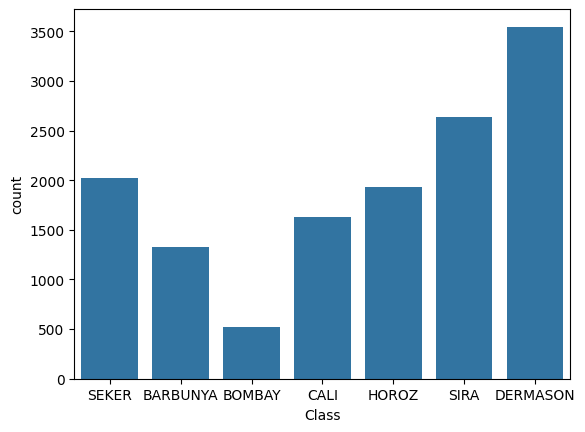

In [17]:
df.drop_duplicates()

#rozkład klas:
sns.countplot(data = df, x = 'Class')

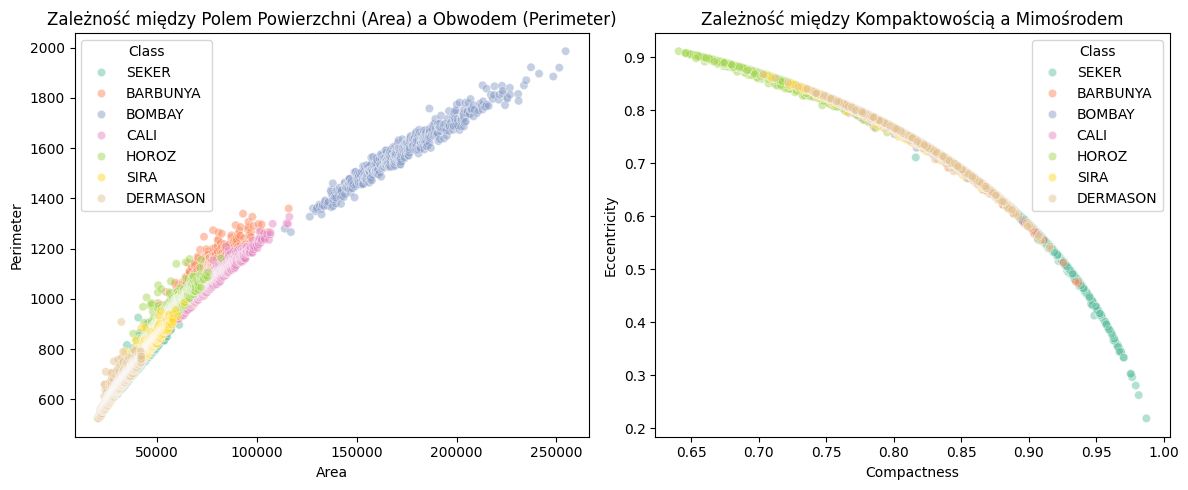

In [22]:
#przestrzenny rozkład klas
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='Area', y='Perimeter', hue='Class', alpha=0.5, palette='Set2')
plt.title('Zależność między Polem Powierzchni (Area) a Obwodem (Perimeter)')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Compactness', y='Eccentricity', hue='Class', alpha=0.5, palette='Set2')
plt.title('Zależność między Kompaktowością a Mimośrodem')

plt.tight_layout()
plt.show()

In [23]:
#podział zbioru danych
X = df.drop(columns='Class')
y = df['Class']

In [26]:
#preprocessing
scaler = StandardScaler()
X = scaler.fit_transform(X)

#Zadanie 2 - algorytm K-means

Inercja dla k=5: 26157.67


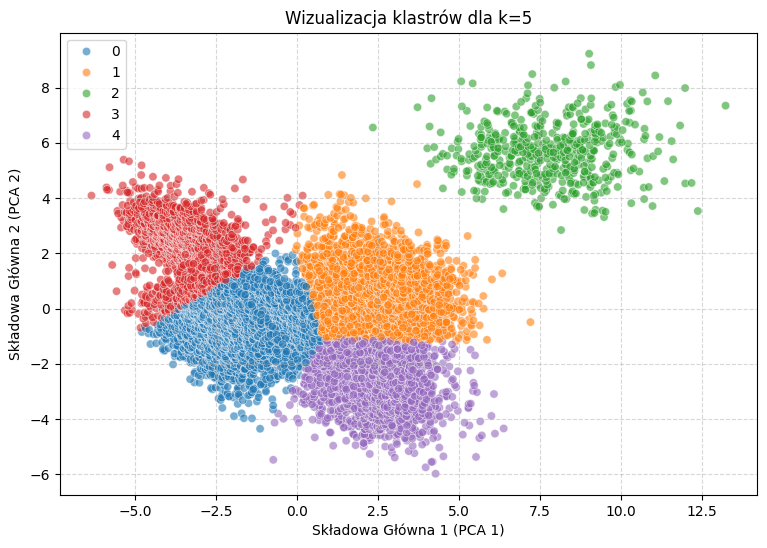

In [34]:
k_1 = 5
kmeans = KMeans(n_clusters=k_1, random_state=42, n_init=15)
kmeans.fit(X)
print(f'Inercja dla k={k_1}: {kmeans.inertia_:.2f}')

#funkcja do wizualizacji wyniku klasteryzacji
def kmeans_result(X, k_labels, title):
  pca = PCA(n_components=2)
  X_pca = pca.fit_transform(X)

  plt.figure(figsize=(9, 6))
  sns.scatterplot(
        x=X_pca[:, 0], y=X_pca[:, 1],
        hue=k_labels,
        palette='tab10', alpha=0.6, legend='full'
    )
  plt.title(title)
  plt.xlabel('Składowa Główna 1 (PCA 1)')
  plt.ylabel('Składowa Główna 2 (PCA 2)')
  plt.grid(True, linestyle='--', alpha=0.5)
  plt.show()

#próbne wywołanie funkjci dla pierwszego wybranego k
kmeans_result(X, kmeans.labels_, f"Wizualizacja klastrów dla k={k_1}")

In [39]:
#deklaracja miary purity, ponieważ nie ma jej wbudowanej w bibliotece

def purity_score(y_true, y_pred):
  matrix = contingency_matrix(y_true, y_pred)
  return np.sum(np.amax(matrix, axis=0)) / np.sum(matrix)

k_range = range(2, 12)

list_inertia = []
list_silhouette = []
list_purity = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    pred_labels = km.fit_predict(X)

    list_inertia.append(km.inertia_)
    list_silhouette.append(silhouette_score(X, pred_labels))
    list_purity.append(purity_score(y, pred_labels))


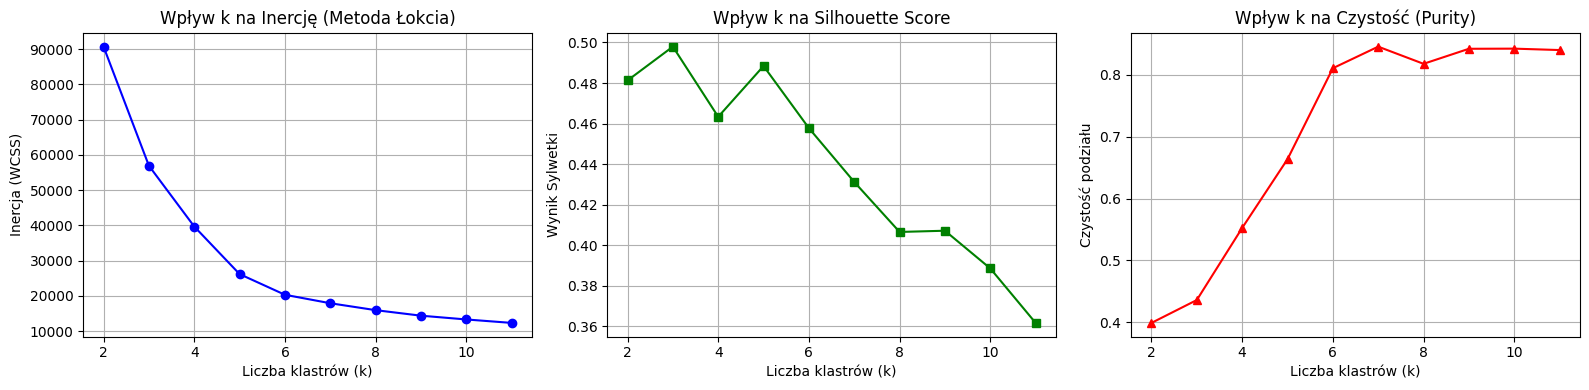

In [40]:
#wykresy porównawcze

plt.figure(figsize=(16, 4))

#Inercja
plt.subplot(1, 3, 1)
plt.plot(k_range, list_inertia, marker='o', color='b', linestyle='-')
plt.title('Wpływ k na Inercję (Metoda Łokcia)')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Inercja (WCSS)')
plt.grid(True)

#Silhouette Score
plt.subplot(1, 3, 2)
plt.plot(k_range, list_silhouette, marker='s', color='g', linestyle='-')
plt.title('Wpływ k na Silhouette Score')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Wynik Sylwetki')
plt.grid(True)

#Purity Score
plt.subplot(1, 3, 3)
plt.plot(k_range, list_purity, marker='^', color='r', linestyle='-')
plt.title('Wpływ k na Czystość (Purity)')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Czystość podziału')
plt.grid(True)

plt.tight_layout()
plt.show()

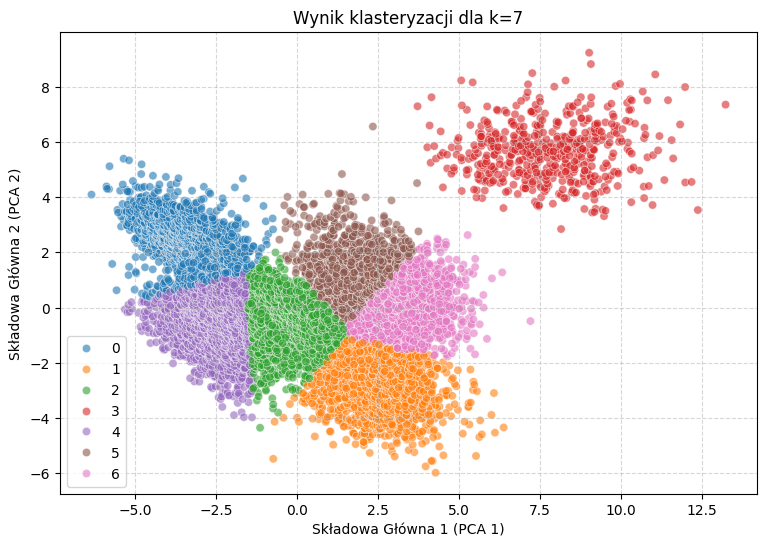

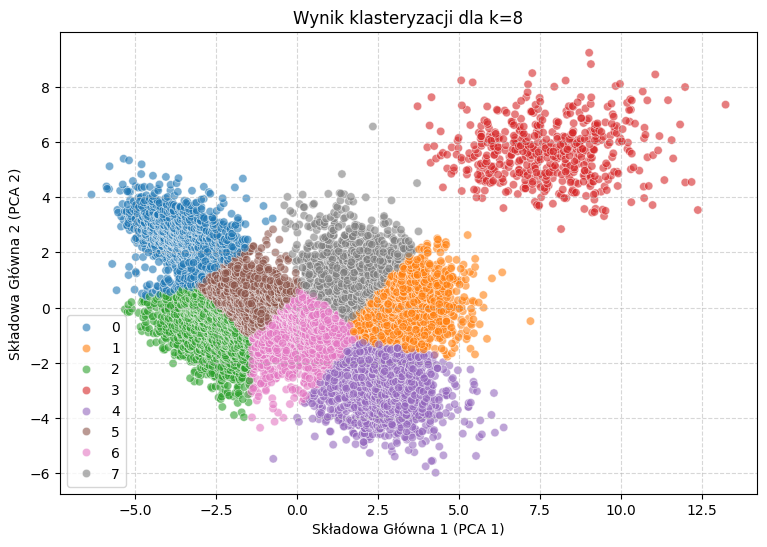

In [41]:
#Wizualizacja dla k = 7 i 8
km_7 = KMeans(n_clusters=7, random_state=42, n_init=10).fit(X)
kmeans_result(X, km_7.labels_, "Wynik klasteryzacji dla k=7")

km_8 = KMeans(n_clusters=8, random_state=42, n_init=10).fit(X)
kmeans_result(X, km_8.labels_, "Wynik klasteryzacji dla k=8")

# Zadanie 3 - Klasteryzacja aglomeracyjna


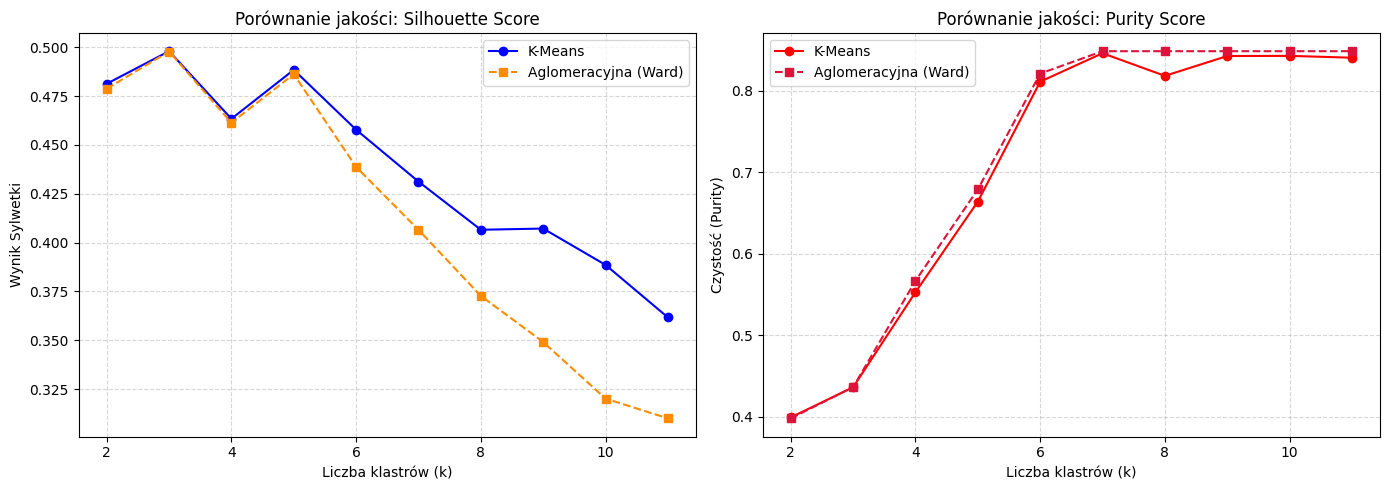

In [43]:

agg_silhouette = []
agg_purity = []

for k in k_range:
    agg = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    labels = agg.fit_predict(X)

    agg_silhouette.append(silhouette_score(X, labels))
    agg_purity.append(purity_score(y, labels))

plt.figure(figsize=(14, 5))

#porównanie Silhouette Score
plt.subplot(1, 2, 1)
plt.plot(k_range, list_silhouette, marker='o', label='K-Means', color='b')
plt.plot(k_range, agg_silhouette, marker='s', label='Aglomeracyjna (Ward)', color='darkorange', linestyle='--')
plt.title('Porównanie jakości: Silhouette Score')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Wynik Sylwetki')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

#Porównanie Purity Score
plt.subplot(1, 2, 2)
plt.plot(k_range, list_purity, marker='o', label='K-Means', color='r')
plt.plot(k_range, agg_purity, marker='s', label='Aglomeracyjna (Ward)', color='crimson', linestyle='--')
plt.title('Porównanie jakości: Purity Score')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Czystość (Purity)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [44]:
#mierzenie czasu

import time

print("\nPOMIAR CZASU (dla k=7) ---")

#dla kmeans
start_km = time.perf_counter()
km_benchmark = KMeans(n_clusters=7, random_state=42, n_init=10)
km_benchmark.fit(X)
end_km = time.perf_counter()
czas_km = end_km - start_km

#dla klasteryzacji aglomeracyjnej
start_agg = time.perf_counter()
agg_benchmark = AgglomerativeClustering(n_clusters=7, metric='euclidean', linkage='ward')
agg_benchmark.fit(X)
end_agg = time.perf_counter()
czas_agg = end_agg - start_agg

print(f"Czas wykonania K-Means: {czas_km:.5f} sekund")
print(f"Czas wykonania Klasteryzacji Aglomeracyjnej: {czas_agg:.5f} sekund")
print(f"Algorytm K-Means był {czas_agg / czas_km:.1f}x szybszy.")


POMIAR CZASU (dla k=7) ---
Czas wykonania K-Means: 0.18444 sekund
Czas wykonania Klasteryzacji Aglomeracyjnej: 12.16380 sekund
Algorytm K-Means był 65.9x szybszy.
